In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\SREENITHI\Downloads\Train_Test_Network_dataset\Train_Test_Network_dataset\train_test_network.csv") 

print(df.shape)
print(df.columns)
df.head()

(211043, 44)
Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [ ]:

df.info()
print(df.isnull().sum().sort_values(ascending=False))

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,211043.000000,211043.000000,211043.000000,2.110430e+05,2.110430e+05,2.110430e+05,211043.000000,2.110430e+05,211043.000000,2.110430e+05,211043.000000,211043.000000,211043.000000,211043.000000,2.110430e+05,211043.000000,211043.000000
mean,38646.519543,3495.153770,7.700887,2.581136e+05,2.588046e+05,3.443234e+04,9.595220,7.760822e+02,3.846861,1.584687e+03,227.630805,3.610909,0.123989,0.065418,1.449295e+02,0.303905,0.763081
std,19307.271048,10191.624778,564.141946,1.709490e+07,1.802563e+07,5.261621e+06,91.778821,2.229703e+04,330.705796,1.901795e+05,2720.713562,23.797747,0.598804,9.243405,3.047244e+04,8.270377,0.425193
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,34608.000000,65.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,44754.000000,80.000000,0.000170,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,8.200000e+01,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,51133.000000,1253.000000,0.054196,1.300000e+02,8.900000e+01,0.000000e+00,4.000000,4.150000e+02,2.000000,1.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000


label
1    161043
0     50000
Name: count, dtype: int64


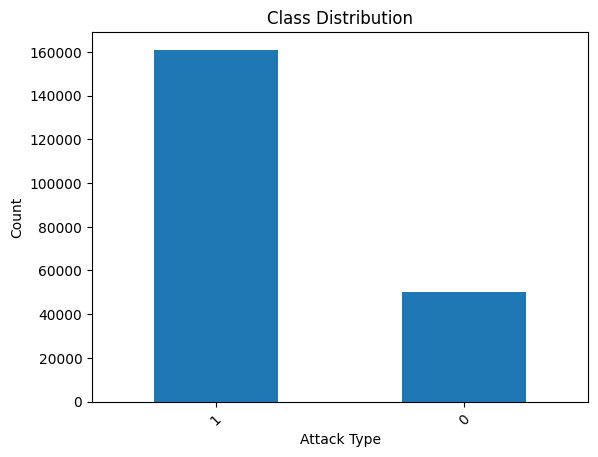

In [ ]:

target_col = 'label'

print(df[target_col].value_counts())


plt.figure()
df[target_col].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 17
Categorical: 27


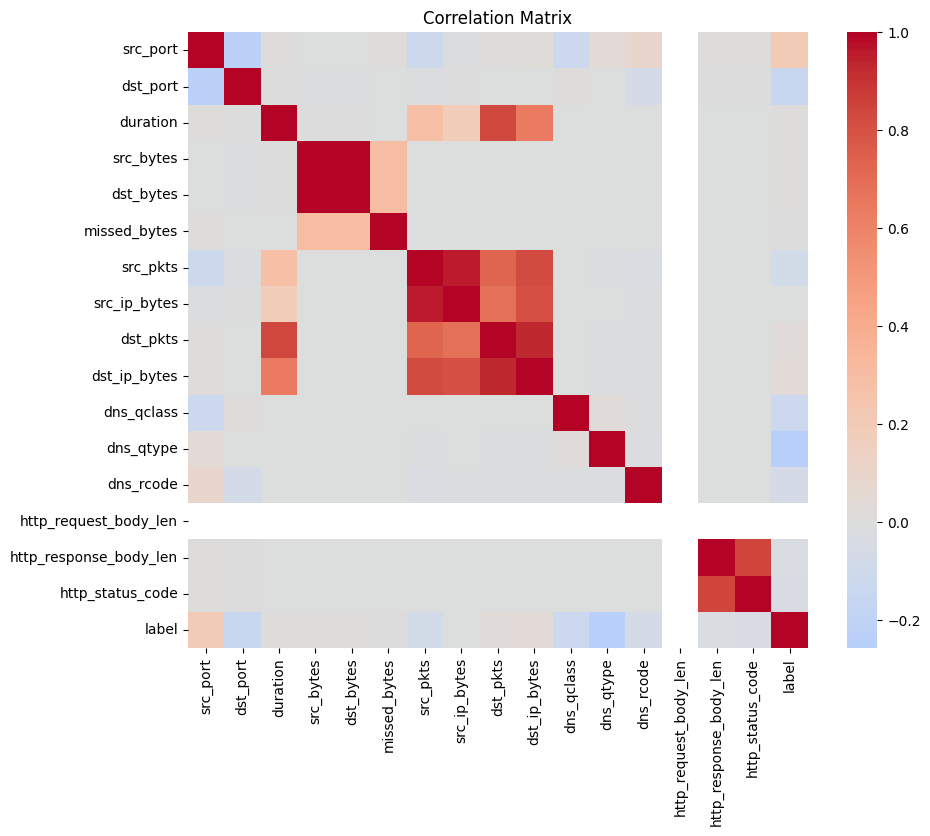

In [ ]:

sample_df = df[num_cols].sample(n=5000, random_state=42)

corr = sample_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

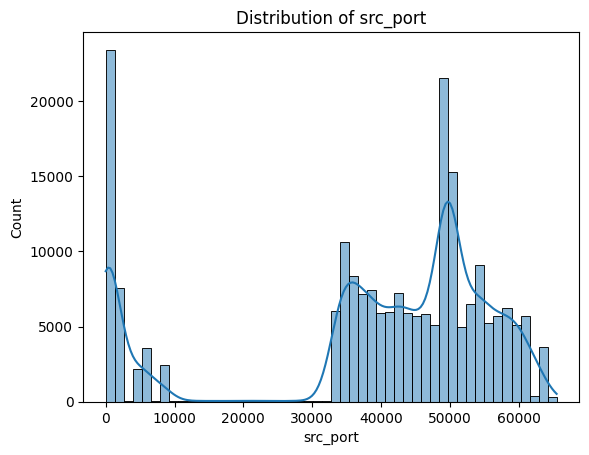

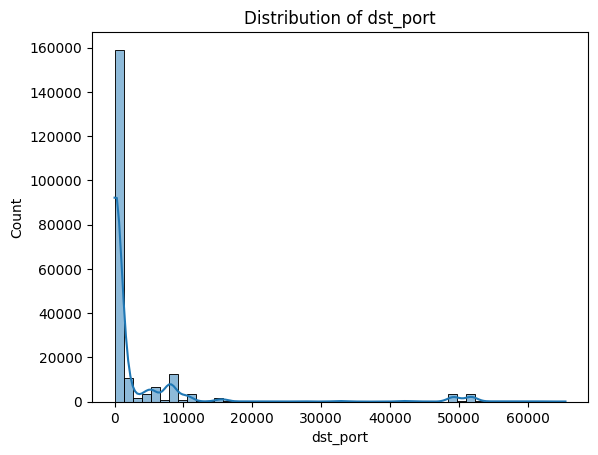

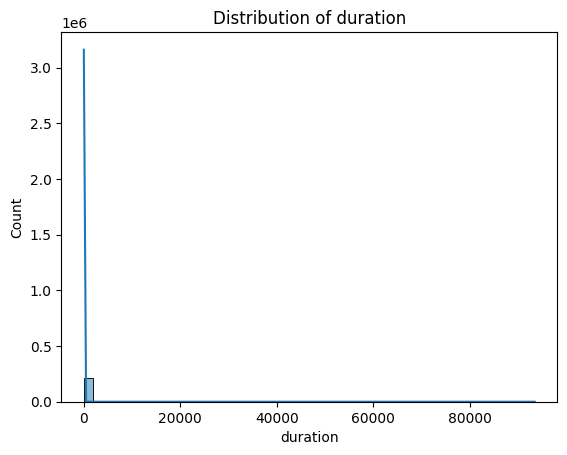

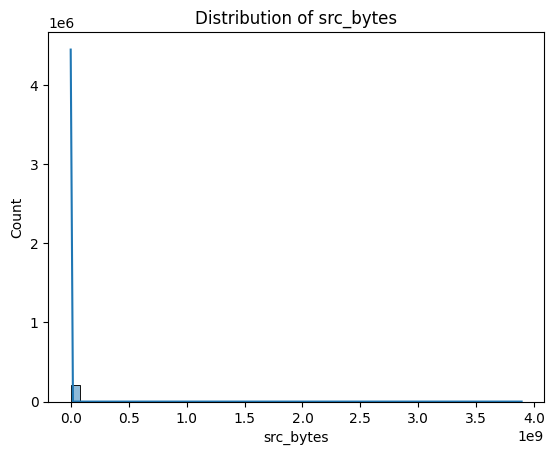

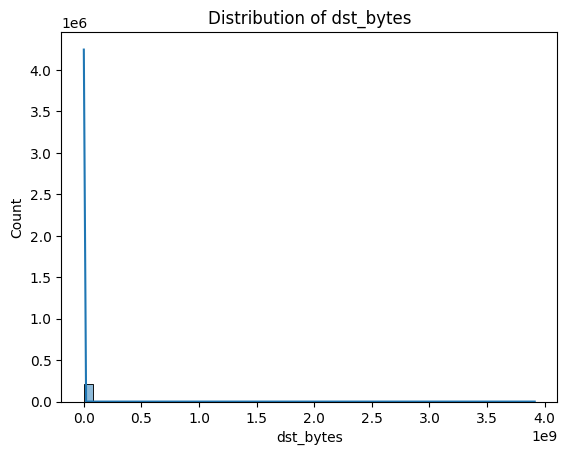

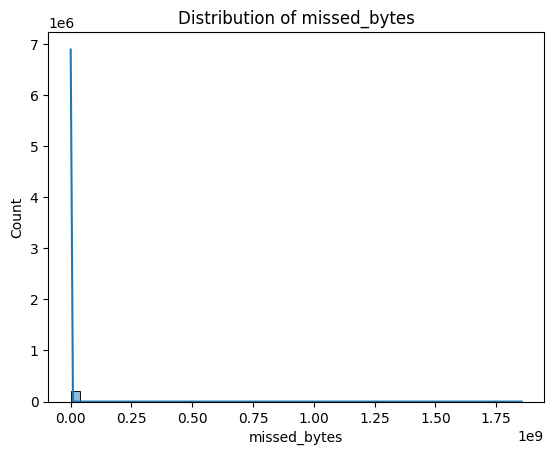

In [ ]:

features_to_plot = num_cols[:6] 
for col in features_to_plot:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

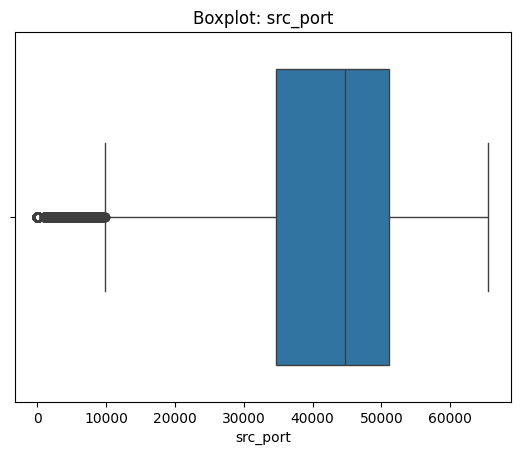

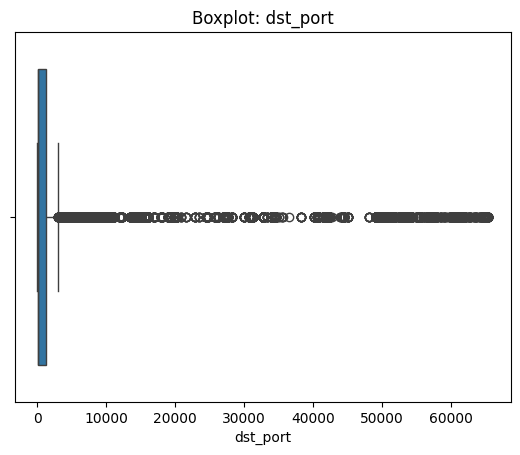

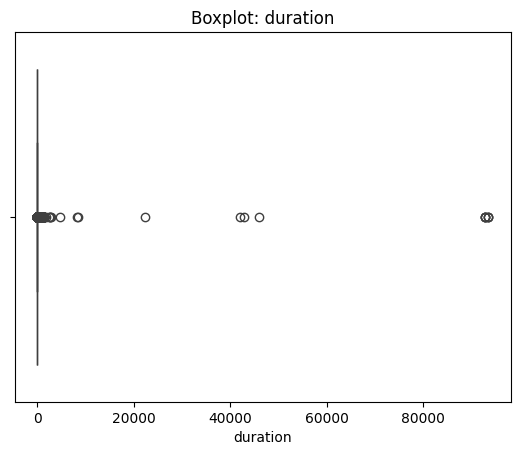

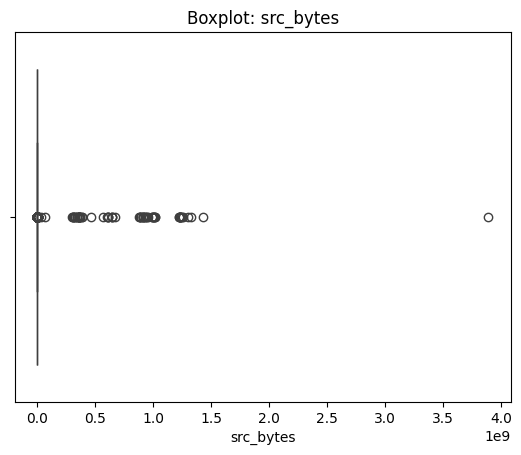

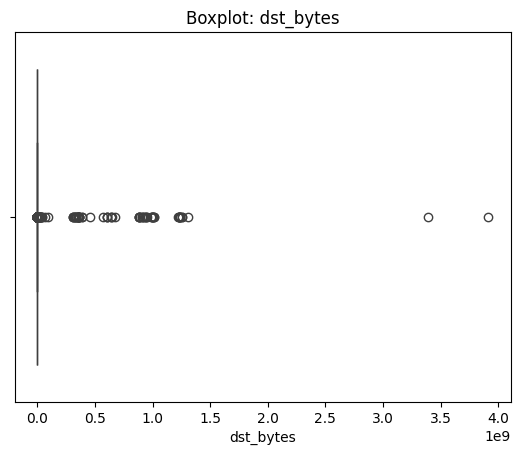

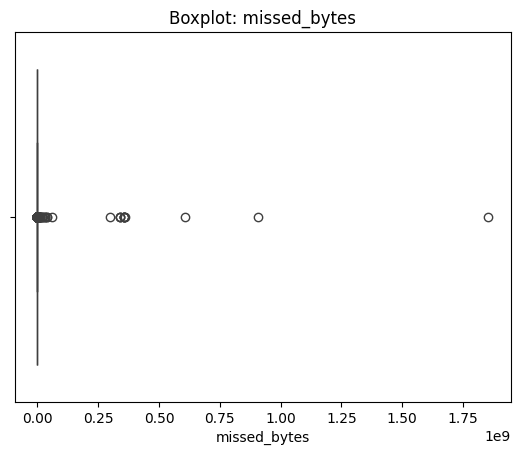

In [9]:
for col in features_to_plot:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

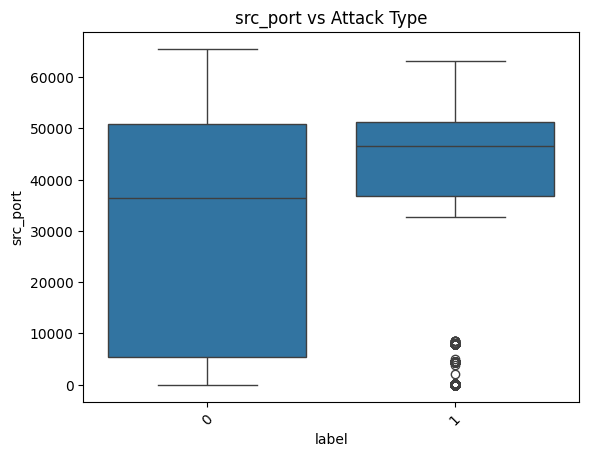

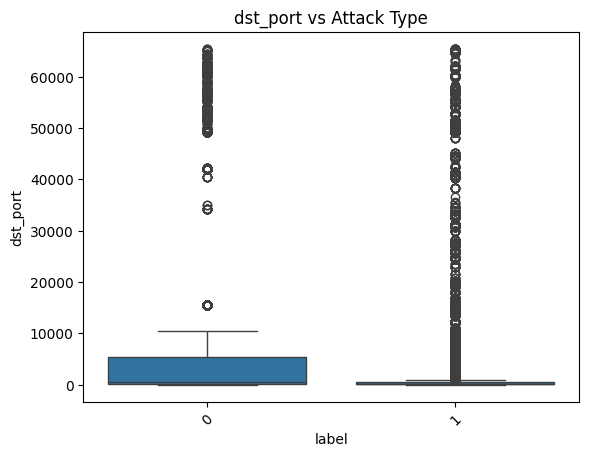

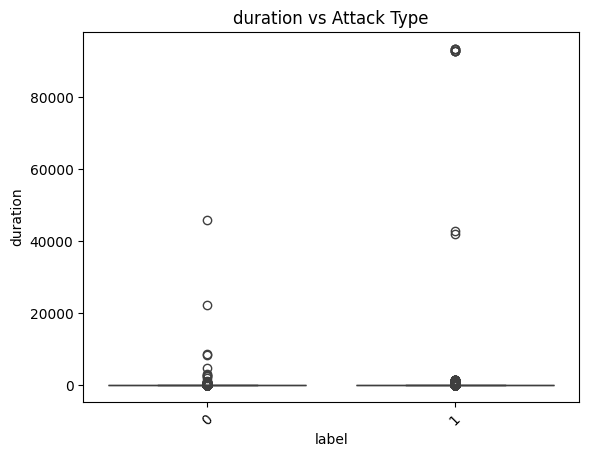

In [ ]:

for col in features_to_plot[:3]:
    plt.figure()
    sns.boxplot(x=target_col, y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Attack Type")
    plt.show()

In [11]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 20569


In [ ]:

class_dist = df[target_col].value_counts(normalize=True) * 100
print(class_dist)

label
1    77.928746
0    22.071254
Name: proportion, dtype: float64


In [2]:
print("\n Final Client-wise Performance ")
for cid in range(NUM_CLIENTS):
    acc, f1 = get_metrics(models[cid], X_test_tensor, y_test_tensor)
    print(f"Client {cid} ({models[cid].__class__.__name__}): Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")

ens_acc = accuracy_score(y_test_global, y_pred_ens)
ens_f1 = f1_score(y_test_global, y_pred_ens, average="weighted")


 Final Client-wise Performance 
Client 0 (Client0_MLP): Test Acc = 0.9574, Test F1 = 0.9607
Client 1 (Client1_MLP): Test Acc = 0.6325, Test F1 = 0.7200
Client 2 (Client2_ResMLP): Test Acc = 0.8818, Test F1 = 0.8478
Client 3 (Client3_BiGRU): Test Acc = 0.9577, Test F1 = 0.9533
Client 4 (Client4_TabAttention): Test Acc = 0.9501, Test F1 = 0.9444
Client 5 (Client5_CNN1D): Test Acc = 0.9561, Test F1 = 0.9599


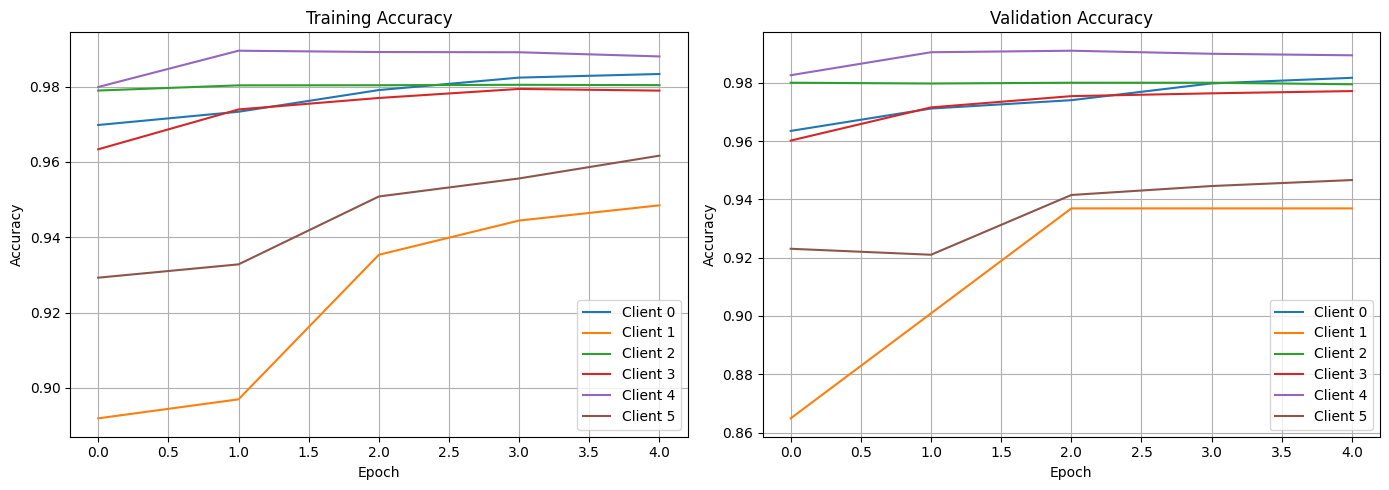

In [3]:

plt.figure(figsize=(14, 5))

# Train Accuracy
plt.subplot(1, 2, 1)
for i in range(NUM_CLIENTS):
    plt.plot(history_train[i], label=f'Client {i}')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1, 2, 2)
for i in range(NUM_CLIENTS):
    plt.plot(history_val[i], label=f'Client {i}')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()